In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_collection.file.file_paths import FilePaths

In [15]:
mastery_matrix = pd.read_csv(FilePaths.mastery_matrix_file())
player_ids = pd.read_csv(FilePaths.viz_player_ids_file())
champ_popularity = mastery_matrix.sum().sort_values()

In [16]:
all_scores = mastery_matrix.values.flatten()
mastery_values = mastery_matrix.values
print(f'Mean Score: {all_scores.mean():.3f}')
print(f'std: {all_scores.std():.3f}')

Mean Score: 0.047
std: 0.127


(array([8.72763661, 0.60785224, 0.26434396, 0.13698271, 0.07775233,
        0.04854911, 0.03117004, 0.02090738, 0.01509996, 0.06970566]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

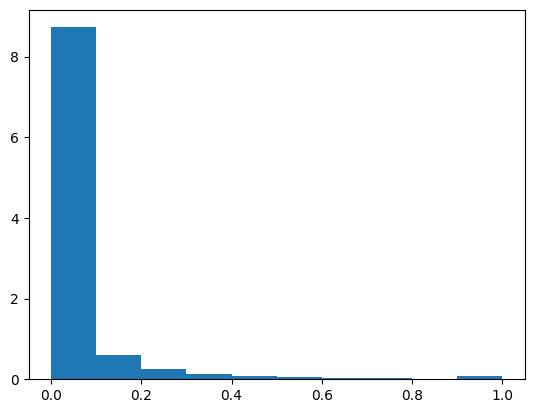

In [19]:
plt.hist(all_scores, density=True)

(array([2626968.,  182960.,   79566.,   41231.,   23403.,   14613.,
           9382.,    6293.,    4545.,   20981.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

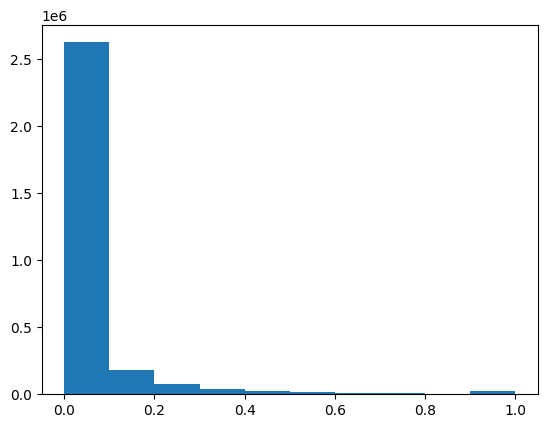

In [20]:
plt.hist(all_scores, density=False)

(array([182958.,  79564.,  41231.,  23405.,  14611.,   9382.,   6294.,
          4544.,  20981.]),
 array([0.10000138, 0.20000123, 0.30000107, 0.40000092, 0.50000077,
        0.60000061, 0.70000046, 0.80000031, 0.90000015, 1.        ]),
 <BarContainer object of 9 artists>)

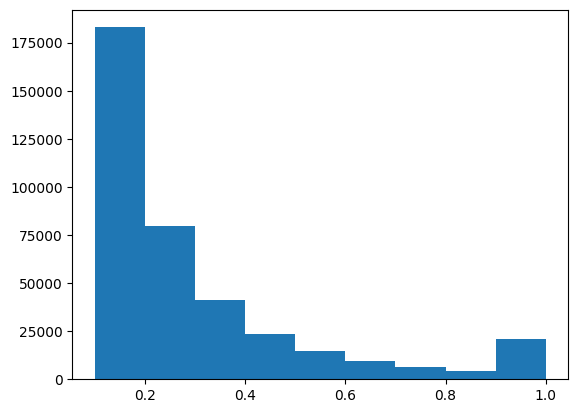

In [21]:
zeros_removed = all_scores[all_scores>0.1]
plt.hist(zeros_removed, bins=9) 

In [22]:
print('Sum of Mastery Scores - correlated with champion popularity')
print(champ_popularity)

Sum of Mastery Scores - correlated with champion popularity
Yunara           134.736002
Renata Glasc     217.370861
Ambessa          221.135522
Rek'Sai          238.218671
Aurora           244.670778
                   ...     
Yasuo           2244.344924
Ezreal          2435.338336
Jhin            2436.087866
Caitlyn         2441.827822
Lux             2474.244172
Length: 171, dtype: float64


## Check whether different champion players have different preferences

There is evidence that players who frequently play Yasuo play champions opposite of Lux, since Yasuo players have a much lower average mastery score on champions such as Lux, MissFortune, and Ashe while they play more Zed, Yone, and Akali on average. This makes sense from a gameplay point of view, since champions such as Zed, Yone, and Akali play the same lane as Yasuo (mid/top), and are also part of the Assassin class. Lux takes the mid/bottom lane role, however her play style is to support the team and provide long distance burst damage as opposed to Yasuo's riskier playstyle of assassinating the enemy's backline in melee range, putting himself at risk. Miss Fortune and Ashe are marksmen that are primarily played in the bottom lane role whose job it is to provide consistent long distance damage.

In [27]:
s = mastery_matrix.mean().sort_values()
yasuo = mastery_matrix.loc[(mastery_matrix['Yasuo']==1.00)]
yasuo = yasuo.mean().sort_values()
#yasuo = (yasuo-s).sort_values()
lux = mastery_matrix.loc[(mastery_matrix['Lux']==1.00)]
lux = lux.mean().sort_values()
#lux = (lux-s).sort_values()
print('Top 10 Average Mastery Scores of Sampled Players')
print(s.tail(10))
print('Average 10 Average Mastery Scores of Lux Players')
print(lux.tail(10))
print('Top 10 Average Mastery Scores of Yasuo Players')
print(yasuo.tail(10))

Top 10 Average Mastery Scores of Sampled Players
Vayne           0.095417
Jinx            0.098120
Kai'Sa          0.103144
Miss Fortune    0.112830
Ashe            0.115518
Yasuo           0.127505
Ezreal          0.138356
Jhin            0.138398
Caitlyn         0.138724
Lux             0.140566
dtype: float64
Average 10 Average Mastery Scores of Lux Players
Nami            0.105181
Senna           0.112257
Ashe            0.129120
Soraka          0.129129
Seraphine       0.142699
Caitlyn         0.151619
Miss Fortune    0.153466
Ahri            0.164745
Morgana         0.206040
Lux             1.000000
dtype: float64
Top 10 Average Mastery Scores of Yasuo Players
Darius     0.109880
Irelia     0.124611
Lee Sin    0.127736
Kayn       0.133596
Jhin       0.142308
Ezreal     0.149003
Akali      0.163020
Zed        0.178103
Yone       0.204144
Yasuo      1.000000
dtype: float64


In [24]:
s = mastery_matrix.mean().sort_values()
yasuo = mastery_matrix.loc[(mastery_matrix['Yasuo']==1.00)]
yasuo = yasuo.mean().sort_values()
yasuo = (yasuo-s).sort_values()
lux = mastery_matrix.loc[(mastery_matrix['Lux']==1.00)]
lux = lux.mean().sort_values()
lux = (lux-s).sort_values()


print('Top 5 Champions (Popularity)')
print(s.tail(5))
print('Top 5 Champions More Popular With Lux Players')
print(lux.tail(5))
print('Top 5 Champions More Popular with Yasuo Players')
print(yasuo.tail(5))
print('Top 5 Champions Least Popular With Lux Players')
print(lux.head(5))
print('Top 5 Champions Least Popular With Yasuo Players')
print(yasuo.head(5))



Top 5 Champions (Popularity)
Yasuo      0.127505
Ezreal     0.138356
Jhin       0.138398
Caitlyn    0.138724
Lux        0.140566
dtype: float64
Top 5 Champions More Popular With Lux Players
Ahri         0.078960
Soraka       0.085156
Seraphine    0.100387
Morgana      0.122159
Lux          0.859434
dtype: float64
Top 5 Champions More Popular with Yasuo Players
Irelia    0.058257
Akali     0.075049
Zed       0.106196
Yone      0.118885
Yasuo     0.872495
dtype: float64
Top 5 Champions Least Popular With Lux Players
Yasuo    -0.093785
Jhin     -0.064196
Kayn     -0.063231
Lucian   -0.059385
Yone     -0.056499
dtype: float64
Top 5 Champions Least Popular With Yasuo Players
Lux            -0.060603
Miss Fortune   -0.057921
Morgana        -0.048260
Senna          -0.041726
Caitlyn        -0.036806
dtype: float64


array([[<Axes: title={'center': 'Yasuo'}>,
        <Axes: title={'center': 'Zed'}>],
       [<Axes: title={'center': 'Lux'}>, <Axes: >]], dtype=object)

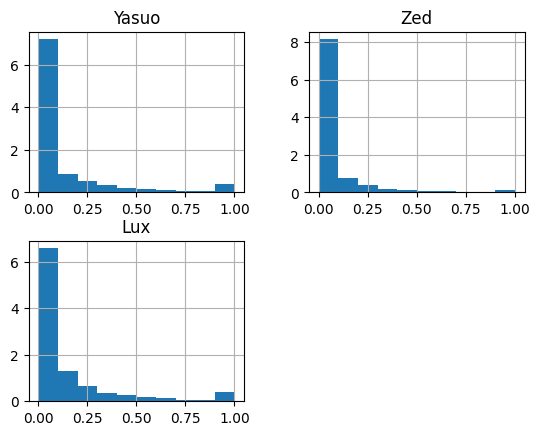

In [25]:
mastery_matrix.hist(column=['Yasuo', 'Zed', 'Lux'], density=True)

array([[<Axes: title={'center': 'Zed'}>, <Axes: title={'center': 'Lux'}>]],
      dtype=object)

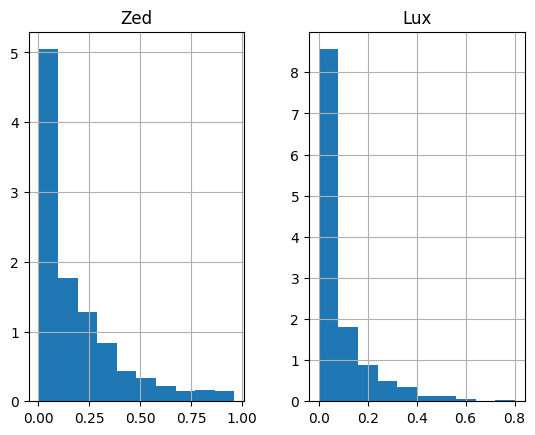

In [26]:
yasuo = mastery_matrix.loc[(df['Yasuo']==1.00)]
yasuo.hist(column=['Zed', 'Lux'], density=True)